# NSKT Test Sample Comparison

This notebook mirrors `analysis/shanghai_model_comparison.ipynb` for NSKT data. It loads pretrained `Ours`, `UNet`, and `Super SloMo` models plus EDEN predictions generated from the same cached start/end frames, samples one NSKT test example for a selected Reynolds number, caches predictions for all intermediate snapshots, and visualizes selected interpolation steps for direct comparison.

In [1]:
from pathlib import Path
import io
import os
import subprocess
import sys

import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
import numpy as np
import torch
from torch_ema import ExponentialMovingAverage

CANDIDATE_ROOTS = [Path.cwd(), Path.cwd().parent]
REPO_ROOT = next((path.resolve() for path in CANDIDATE_ROOTS if (path / "src").exists()), None)
if REPO_ROOT is None:
    raise RuntimeError("Could not locate repo root containing ./src")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from datasets.data_nskt_updated import NSKT_eval, RE_EVAL_LIST
from eval_super_slomo import run_super_slomo_step
from src.diffusion_model import DiffusionModel
from src.flex import FLEX
from src.unet import UNet
from src.utilities import materialize_checkpoint_modules
import src.super_slomo as slomo_model

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Repo root: {REPO_ROOT}")
print(f"Using device: {DEVICE}")


Repo root: /pscratch/sd/p/puren93/puren/Interp-DM
Using device: cuda


In [2]:
CONFIG = {
    "scratch_dir": Path("/global/cfs/cdirs/m4633/foundationmodel/nskt_tensor/"),
    "sample_index": 2,
    "re_id": 9,  # RE_EVAL_LIST index; 5=12000, 7=24000, 9=36000, -1 cycles all eval Re values.
    "patch_size": 256,
    "crop_size": 256,
    "stride": 32,
    "total_interp_steps": 20,
    "flex_time_steps": 3,
    "flex_model_size": "small",
    "flex_mlp_ratio": 2,
    "use_scalar_film": True,
    "use_spatial_cond": True,
    "spatial_cond_scales": [32, 16],
    "spatial_cond_mode": "gated",
    "prediction_type": "v",
    "unet_base_width": 128,
    "flex_checkpoint": REPO_ROOT / "checkpoints/checkpoint_Model_ft_FLEX3_small_mlp2_Data_nskt_Optim_adam_cosine_lr0.0001_epoch300_patchsize256_stride32_T20_TfixedFalse_best.pt",
    "unet_checkpoint": REPO_ROOT / "checkpoints/checkpoint_Model_ft_UNet_Data_nskt_Optim_adam_lr0.0001_epoch200_stride32_T20_TfixedFalse.pt",
    "super_slomo_checkpoint": REPO_ROOT / "checkpoints/checkpoint_Model_SuperSloMo_Data_nskt_Optim_adam_lr6e-05_epoch200_stride32_T20_TfixedTrue.pt",
    "cache_dir": REPO_ROOT / "analysis",
    "force_refresh": False,
    "random_seed": 0,
    "selected_steps": [5, 10, 15, 20],
    "display_colormap": "RdBu_r",
    "percentile_clip": 99.0,
    "symmetric_vlim": True,
}

if CONFIG["re_id"] >= 0:
    CONFIG["re_value"] = RE_EVAL_LIST[CONFIG["re_id"]]
    cache_re_label = f"re{CONFIG['re_value']}"
else:
    CONFIG["re_value"] = -1
    cache_re_label = "reall"
CONFIG["cache_path"] = CONFIG["cache_dir"] / f"nskt_{cache_re_label}_sample_{CONFIG['sample_index']}_comparison.npz"
CONFIG["eden_python"] = Path("/pscratch/sd/p/puren93/conda_env/eden/bin/python")
CONFIG["eden_config_path"] = REPO_ROOT / "EDEN/configs/eval_eden_nskt.yaml"
CONFIG["eden_vae_checkpoint"] = REPO_ROOT / "EDEN/output/experiments-EDEN_VAE/014/checkpoints/0020000.pt"
CONFIG["eden_dit_checkpoint"] = REPO_ROOT / "EDEN/output/experiments-EDEN_DiT/015/checkpoints/0012000.pt"
CONFIG["eden_same_inputs_cache_path"] = CONFIG["cache_dir"] / f"nskt_{cache_re_label}_sample_{CONFIG['sample_index']}_eden_same_inputs.npz"

for key in ["flex_checkpoint", "unet_checkpoint", "super_slomo_checkpoint"]:
    path = Path(CONFIG[key])
    print(f"{key}: {path}")
    if not path.exists():
        raise FileNotFoundError(f"Missing required path for {key}: {path}")

if not CONFIG["scratch_dir"].exists():
    raise FileNotFoundError(f"Missing NSKT scratch_dir: {CONFIG['scratch_dir']}")
for key in ["eden_python", "eden_config_path", "eden_vae_checkpoint", "eden_dit_checkpoint"]:
    path = Path(CONFIG[key])
    if not path.exists():
        raise FileNotFoundError(f"Missing required EDEN path for {key}: {path}")

CONFIG["cache_dir"].mkdir(parents=True, exist_ok=True)
print(f"scratch_dir: {CONFIG['scratch_dir']}")
print(f"eden_same_inputs_cache_path: {CONFIG['eden_same_inputs_cache_path']}")
print(f"re_id: {CONFIG['re_id']}  re_value: {CONFIG['re_value']}")
print(f"cache_path: {CONFIG['cache_path']}")
print(f"force_refresh: {CONFIG['force_refresh']}")
print(f"selected_steps: {CONFIG['selected_steps']}")


flex_checkpoint: /pscratch/sd/p/puren93/puren/Interp-DM/checkpoints/checkpoint_Model_ft_FLEX3_small_mlp2_Data_nskt_Optim_adam_cosine_lr0.0001_epoch300_patchsize256_stride32_T20_TfixedFalse_best.pt
unet_checkpoint: /pscratch/sd/p/puren93/puren/Interp-DM/checkpoints/checkpoint_Model_ft_UNet_Data_nskt_Optim_adam_lr0.0001_epoch200_stride32_T20_TfixedFalse.pt
super_slomo_checkpoint: /pscratch/sd/p/puren93/puren/Interp-DM/checkpoints/checkpoint_Model_SuperSloMo_Data_nskt_Optim_adam_lr6e-05_epoch200_stride32_T20_TfixedTrue.pt
scratch_dir: /global/cfs/cdirs/m4633/foundationmodel/nskt_tensor
eden_same_inputs_cache_path: /pscratch/sd/p/puren93/puren/Interp-DM/analysis/nskt_re36000_sample_2_eden_same_inputs.npz
re_id: 9  re_value: 36000
cache_path: /pscratch/sd/p/puren93/puren/Interp-DM/analysis/nskt_re36000_sample_2_comparison.npz
force_refresh: False
selected_steps: [5, 10, 15, 20]


In [3]:
def load_flex_model(config, device):
    encoder, task_encoder, task_encoder_end, decoder = FLEX(
        image_size=config["patch_size"],
        in_channels=1,
        out_channels=1,
        model_size=config["flex_model_size"],
        mlp_ratio=config["flex_mlp_ratio"],
        use_scalar_film=config["use_scalar_film"],
        use_spatial_cond=config["use_spatial_cond"],
        spatial_cond_scales=config["spatial_cond_scales"],
        spatial_cond_mode=config["spatial_cond_mode"],
    )
    model = DiffusionModel(
        encoder=encoder.to(device),
        decoder=decoder.to(device),
        task_encoder=task_encoder.to(device),
        task_encoder_end=task_encoder_end.to(device) if task_encoder_end is not None else None,
        diff_steps=config["flex_time_steps"],
        prediction_type=config["prediction_type"],
        criterion=torch.nn.L1Loss(),
        dt_normalization_scale=float(config["total_interp_steps"]),
    )
    checkpoint = torch.load(config["flex_checkpoint"], map_location="cpu", weights_only=True)
    materialize_checkpoint_modules(model, checkpoint["model"])
    model.load_state_dict(checkpoint["model"])
    ema = ExponentialMovingAverage(model.parameters(), decay=0.999)
    if "ema" in checkpoint:
        ema.load_state_dict(checkpoint["ema"])
    model.eval()
    return model, ema


def load_unet_model(config, device):
    model = UNet(
        image_size=config["patch_size"],
        in_channels=2,
        out_channels=1,
        base_width=config["unet_base_width"],
    ).to(device)
    checkpoint = torch.load(config["unet_checkpoint"], map_location="cpu", weights_only=True)
    model.load_state_dict(checkpoint["model"])
    model.eval()
    return model


def load_super_slomo_model(config, device):
    slomo_model.configure_time_grid("nskt", config["total_interp_steps"])
    flow_comp = slomo_model.UNet(2, 4).to(device)
    flow_interp = slomo_model.UNet(12, 5).to(device)
    back_warp = slomo_model.backWarp(config["patch_size"], config["patch_size"], str(device)).to(device)

    checkpoint = torch.load(config["super_slomo_checkpoint"], map_location="cpu", weights_only=True)
    flow_comp.load_state_dict(checkpoint["flowComp"])
    flow_interp.load_state_dict(checkpoint["ArbTimeFlowIntrp"])

    flow_comp.eval()
    flow_interp.eval()
    return flow_comp, flow_interp, back_warp


np.random.seed(CONFIG["random_seed"])
torch.manual_seed(CONFIG["random_seed"])

# NSKT_eval uses random patch origins. The seed above makes the selected sample reproducible
# as long as this cell is run before materializing a new cache.
dataset = NSKT_eval(
    patch_size=CONFIG["patch_size"],
    crop_size=CONFIG["crop_size"],
    stride=CONFIG["stride"],
    num_interp_steps=CONFIG["total_interp_steps"],
    re_id=CONFIG["re_id"],
    scratch_dir=str(CONFIG["scratch_dir"]),
)
print(f"NSKT test samples: {len(dataset)}")

flex_model, flex_ema = load_flex_model(CONFIG, DEVICE)
unet_model = load_unet_model(CONFIG, DEVICE)
slomo_flow_comp, slomo_flow_interp, slomo_back_warp = load_super_slomo_model(CONFIG, DEVICE)
print("All three pretrained models are loaded.")


NSKT test samples: 2000
All three pretrained models are loaded.


In [4]:
def tensor_to_image(x):
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().float().squeeze().numpy()
    return np.asarray(x).squeeze()


def load_eden_predictions_same_inputs(config, result):
    eden_cache = Path(config["eden_same_inputs_cache_path"])
    if not eden_cache.exists() or config["force_refresh"]:
        save_comparison(result, config["cache_path"])
        cmd = [
            str(config["eden_python"]),
            str(REPO_ROOT / "analysis/generate_eden_same_inputs.py"),
            "--comparison_cache",
            str(config["cache_path"]),
            "--output",
            str(eden_cache),
            "--config",
            str(config["eden_config_path"]),
            "--vae_checkpoint_path",
            str(config["eden_vae_checkpoint"]),
            "--dit_checkpoint_path",
            str(config["eden_dit_checkpoint"]),
            "--seed",
            str(config["random_seed"]),
        ]
        print("Generating EDEN predictions with the same cached start/end frames...")
        subprocess.run(cmd, check=True, cwd=REPO_ROOT)

    loaded = np.load(eden_cache, allow_pickle=False)
    if int(loaded["sample_index"]) != int(result["sample_index"]):
        raise ValueError("EDEN cache sample_index does not match comparison cache.")
    if int(loaded["re_value"]) != int(result["re_value"]):
        raise ValueError("EDEN cache Reynolds number does not match comparison cache.")
    return [tensor_to_image(frame) for frame in loaded["eden"]]


def predict_all_steps(config, dataset, sample_index, device):
    np.random.seed(config["random_seed"])
    torch.manual_seed(config["random_seed"])

    inputs, targets, cond_params = dataset[sample_index]
    condition_start, condition_end = inputs

    condition_start = condition_start.unsqueeze(0).to(device)
    condition_end = condition_end.unsqueeze(0).to(device)
    total_interp_steps, reynolds_number = cond_params
    total_interp_steps = total_interp_steps.unsqueeze(0).to(device)
    reynolds_number = reynolds_number.unsqueeze(0).to(device)

    gt_frames = [tensor_to_image(target) for target in targets]
    flex_preds = []
    unet_preds = []
    slomo_preds = []

    with torch.no_grad():
        with flex_ema.average_parameters():
            for step in range(1, config["total_interp_steps"] + 1):
                target_interp_step = torch.tensor([step], dtype=torch.float32, device=device)

                flex_pred = flex_model.sample(
                    n_sample=1,
                    size=(1, config["patch_size"], config["patch_size"]),
                    cond_snapshot_start=condition_start,
                    cond_snapshot_end=condition_end,
                    fluid_condition=reynolds_number,
                    target_interp_step=target_interp_step,
                    total_interp_steps=total_interp_steps,
                    device=str(device),
                )
                flex_preds.append(tensor_to_image(flex_pred))

                unet_pred = unet_model.sample(
                    condition_start,
                    condition_end,
                    fluid_condition=reynolds_number,
                    target_interp_step=target_interp_step,
                    total_interp_steps=total_interp_steps,
                )
                unet_preds.append(tensor_to_image(unet_pred))

                slomo_pred = run_super_slomo_step(
                    slomo_flow_comp,
                    slomo_flow_interp,
                    slomo_back_warp,
                    condition_start,
                    condition_end,
                    target_interp_step,
                    str(device),
                )
                slomo_preds.append(tensor_to_image(slomo_pred))

    return {
        "sample_index": sample_index,
        "re_id": config["re_id"],
        "re_value": config["re_value"] if config["re_id"] >= 0 else -1,
        "start": tensor_to_image(condition_start),
        "end": tensor_to_image(condition_end),
        "ground_truth": gt_frames,
        "flex": flex_preds,
        "unet": unet_preds,
        "super_slomo": slomo_preds,
    }


def save_comparison(result, save_path):
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    payload = {
        "sample_index": np.array(result["sample_index"], dtype=np.int64),
        "re_id": np.array(result["re_id"], dtype=np.int64),
        "re_value": np.array(result["re_value"], dtype=np.int64),
        "start": np.asarray(result["start"], dtype=np.float32),
        "end": np.asarray(result["end"], dtype=np.float32),
        "ground_truth": np.stack(result["ground_truth"], axis=0).astype(np.float32),
        "flex": np.stack(result["flex"], axis=0).astype(np.float32),
        "unet": np.stack(result["unet"], axis=0).astype(np.float32),
        "super_slomo": np.stack(result["super_slomo"], axis=0).astype(np.float32),
    }
    if "eden" in result:
        payload["eden"] = np.stack(result["eden"], axis=0).astype(np.float32)
    np.savez_compressed(save_path, **payload)


def load_comparison(save_path):
    loaded = np.load(save_path, allow_pickle=False)
    result = {
        "sample_index": int(loaded["sample_index"]),
        "re_id": int(loaded["re_id"]),
        "re_value": int(loaded["re_value"]),
        "start": loaded["start"],
        "end": loaded["end"],
        "ground_truth": [frame for frame in loaded["ground_truth"]],
        "flex": [frame for frame in loaded["flex"]],
        "unet": [frame for frame in loaded["unet"]],
        "super_slomo": [frame for frame in loaded["super_slomo"]],
    }
    return result


if CONFIG["cache_path"].exists() and not CONFIG["force_refresh"]:
    comparison = load_comparison(CONFIG["cache_path"])
    print(f"Loaded cached comparison from {CONFIG['cache_path']}")
else:
    comparison = predict_all_steps(CONFIG, dataset, CONFIG["sample_index"], DEVICE)
    save_comparison(comparison, CONFIG["cache_path"])
    print(f"Saved comparison to {CONFIG['cache_path']}")

comparison["eden"] = load_eden_predictions_same_inputs(CONFIG, comparison)
print(f"Loaded same-input EDEN predictions from {CONFIG['eden_same_inputs_cache_path']}")

print(f"Prepared predictions for sample index {comparison['sample_index']}")
print(f"Reynolds number: {comparison['re_value']}")
print(f"Number of intermediate frames: {len(comparison['ground_truth'])}")


Loaded cached comparison from /pscratch/sd/p/puren93/puren/Interp-DM/analysis/nskt_re36000_sample_2_comparison.npz
Generating EDEN predictions with the same cached start/end frames...
Saved EDEN same-input predictions to /pscratch/sd/p/puren93/puren/Interp-DM/analysis/nskt_re36000_sample_2_eden_same_inputs.npz
Loaded same-input EDEN predictions from /pscratch/sd/p/puren93/puren/Interp-DM/analysis/nskt_re36000_sample_2_eden_same_inputs.npz
Prepared predictions for sample index 2
Reynolds number: 36000
Number of intermediate frames: 20


Saved figure to /pscratch/sd/p/puren93/puren/Interp-DM/analysis/nskt_re36000_sample_2_comparison.png


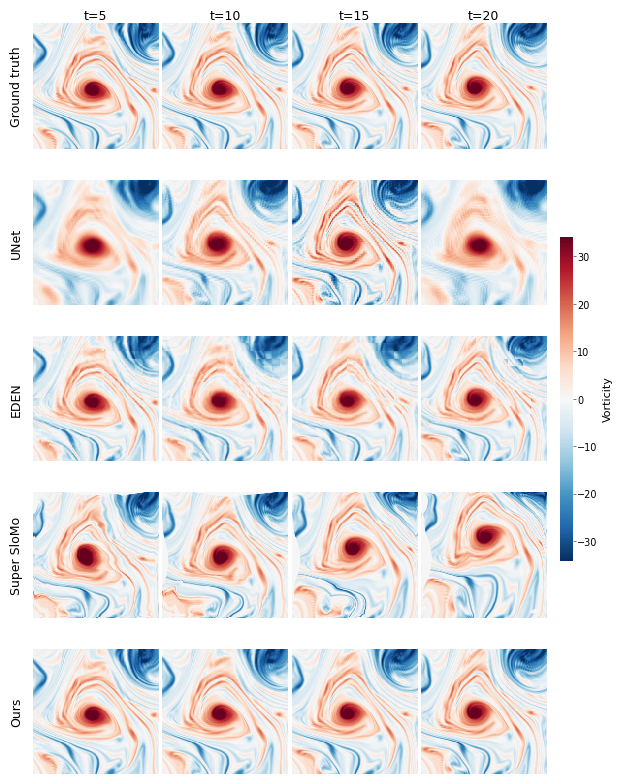

In [7]:
def validate_selected_steps(selected_steps, total_interp_steps):
    if not selected_steps:
        raise ValueError("selected_steps must contain at least one step index.")
    for step in selected_steps:
        if step < 1 or step > total_interp_steps:
            raise ValueError(f"Selected step {step} is out of range 1..{total_interp_steps}.")
    return list(selected_steps)


def compute_display_norm(frames, config):
    values = np.concatenate([np.asarray(frame, dtype=np.float32).ravel() for frame in frames])
    percentile = float(config["percentile_clip"])
    if config["symmetric_vlim"]:
        vmax = np.nanpercentile(np.abs(values), percentile)
        vmax = float(vmax) if np.isfinite(vmax) and vmax > 0 else 1.0
        return mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax), "Vorticity"

    vmin, vmax = np.nanpercentile(values, [100.0 - percentile, percentile])
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
        vmin, vmax = float(np.nanmin(values)), float(np.nanmax(values))
    if vmin == vmax:
        vmin, vmax = vmin - 1.0, vmax + 1.0
    return mcolors.Normalize(vmin=float(vmin), vmax=float(vmax)), "Vorticity"


def visualize_comparison(result, config):
    selected_steps = validate_selected_steps(config["selected_steps"], len(result["ground_truth"]))
    model_rows = [
        ("Ground truth", result["ground_truth"]),
        ("UNet", result["unet"]),
        ("EDEN", result["eden"]),
        ("Super SloMo", result["super_slomo"]),
        ("Ours", result["flex"]),
    ]
    display_frames = [frames[step - 1] for _, frames in model_rows for step in selected_steps]
    cmap = plt.get_cmap(config["display_colormap"])
    norm, colorbar_label = compute_display_norm(display_frames, config)

    fig, axes = plt.subplots(
        len(model_rows),
        len(selected_steps),
        figsize=(1.8 * len(selected_steps), 1.75 * len(model_rows)),
        facecolor="white",
        squeeze=False,
    )

    image_artist = None
    for row_idx, (row_label, frames) in enumerate(model_rows):
        for col_idx, step in enumerate(selected_steps):
            ax = axes[row_idx, col_idx]
            image_artist = ax.imshow(frames[step - 1], cmap=cmap, norm=norm, interpolation="nearest")
            ax.set_xticks([])
            ax.set_yticks([])
            if row_idx == 0:
                ax.set_title(f"t={step}", fontsize=9, pad=3)
            if col_idx == 0:
                ax.set_ylabel(row_label, fontsize=9, rotation=90, ha="center", va="center", labelpad=12)
            for spine in ax.spines.values():
                spine.set_visible(False)

    re_label = f"RE{result['re_value']}" if result["re_value"] >= 0 else "mixed RE"
    #fig.suptitle(f"NSKT {re_label}, sample {result['sample_index']}", fontsize=10, y=0.995)
    fig.subplots_adjust(left=0.15, right=0.9, top=0.92, bottom=0.04, wspace=0.03, hspace=0.08)
    cbar = fig.colorbar(
        image_artist,
        ax=axes,
        orientation="vertical",
        fraction=0.025,
        pad=0.025,
        shrink=0.88,
        aspect=24,
    )
    cbar.set_label(colorbar_label, fontsize=8)
    cbar.outline.set_visible(False)
    cbar.ax.tick_params(labelsize=7, length=2.0, width=0.5, color="#444", pad=1)

    save_path = config["cache_dir"] / f"nskt_re{result['re_value']}_sample_{result['sample_index']}_comparison.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Saved figure to {save_path}")
    plt.show()


visualize_comparison(comparison, CONFIG)



In [ ]:
# # Compact comparison: Ground Truth, Super SloMo, and Ours. No y-axis labels.
# def visualize_compact_gt_slomo_ours(result, config, selected_steps=(5, 20)):
#     selected_steps = validate_selected_steps(selected_steps, len(result["ground_truth"]))
#     rows = [result["ground_truth"], result["super_slomo"], result["flex"]]
#     display_frames = [frames[step - 1] for frames in rows for step in selected_steps]
#     cmap = plt.get_cmap(config["display_colormap"])
#     norm, _ = compute_display_norm(display_frames, config)

#     panels = [frames[step - 1] for frames in rows for step in selected_steps]
#     fig, axes = plt.subplots(1, len(panels), figsize=(1.4 * len(panels), 1.5), facecolor="white")
#     image_artist = None
#     for ax, frame in zip(np.ravel(axes), panels):
#         image_artist = ax.imshow(frame, cmap=cmap, norm=norm, interpolation="nearest")
#         ax.set_xticks([])
#         ax.set_yticks([])
#         ax.set_xlabel("")
#         ax.set_ylabel("")
#         for spine in ax.spines.values():
#             spine.set_visible(False)

#     fig.subplots_adjust(left=0.01, right=0.995, top=0.995, bottom=0.06, wspace=0.1)
#     cbar = fig.colorbar(image_artist, ax=axes, orientation="vertical", fraction=0.028, pad=0.018, shrink=0.88, aspect=18)
#     cbar.outline.set_visible(False)
#     cbar.ax.tick_params(labelsize=8.0, length=1.4, width=0.5, color="#444", pad=1)
#     save_path = config["cache_dir"] / f"nskt_re{result['re_value']}_sample_{result['sample_index']}_gt_slomo_ours.pdf"
#     plt.savefig(save_path, dpi=300, bbox_inches="tight")
#     print(f"Saved GT/Super SloMo/Ours figure to {save_path}")
#     plt.show()


# visualize_compact_gt_slomo_ours(comparison, CONFIG, selected_steps=(5, 20))

